## qubit spec in flux sweep
<a id="qubit_spec_in_flux_sweep"></a>

In [1]:
#env: qcrew

import numpy as np
import pylab as plt
import sys
import os
from os import listdir
from collections import defaultdict
import numpy as np
import h5py
import matplotlib.pyplot as plt

# sys.path.append("C:/Users/qcrew/Desktop/full-enjoy/")
import h5py

# Define folder paths
# _folder_0 = "C:/Users/qcrew/Documents/eunice/data/2026-02-06/"
# _folder_1 = "C:/Users/qcrew/Documents/eunice/data/2026-02-07/"
# filter_time_0 = (22,30) #(18,49) #
# filter_time_1 = (0, 0)
# filter_time_0_end = (23,59) #22,33 #
# filter_time_1_end = (11, 54)

# _folder_0 = "C:/Users/qcrew/Documents/eunice/data/2026-02-08/"
# _folder_1 = "C:/Users/qcrew/Documents/eunice/data/2026-02-09/"
# filter_time_0 = (22,8) #(18,49) #
# filter_time_1 = (0, 0)
# filter_time_0_end = (23,59) #22,33 #
# filter_time_1_end = (5, 46)

_folder_0 = "C:/Users/qcrew/Documents/eunice/data/2026-02-26/"
_folder_1 = "C:/Users/qcrew/Documents/eunice/data/2026-02-27/"
filter_time_0 = (22,25) #(18,49) #
filter_time_1 = (0, 0)
filter_time_0_end = (23,59) #22,33 #
filter_time_1_end = (2, 46)
# Initialize list for filenames
def extract_time(filename):
    """Extracts (hour, minute) from the filename."""
    try:
        parts = filename.split("-")
        hour, minute = int(parts[0]), int(parts[1])
        return hour, minute
    except (ValueError, IndexError):
        return (-1, -1)  # Return invalid values if parsing fails

def process_folder(folder_path, filter_time_0, filter_time_0_end):
    """Processes files in the given folder path and returns filtered filenames."""
    local_filenames = []

    if not os.path.exists(folder_path):
        print(f"Error: Folder '{folder_path}' does not exist!")
        return local_filenames  # Return an empty list instead of None

    print(f"Folder '{folder_path}' exists, scanning files...")
    for _filename in os.listdir(folder_path):
#         print(f"Checking: {_filename}")  # Debugging print

        if _filename.endswith(".hdf5") and "QubitSpec" in _filename:
            time = extract_time(_filename)
#             print(f"Filename: {_filename}, Extracted time: {time}")  # Debugging print

            if time != (-1, -1) and filter_time_0_end >= time >= filter_time_0:
                local_filenames.append(os.path.join(folder_path, _filename))

    return local_filenames  # Return the list of filtered filenames

# Process both folders and collect filenames
grouped_filenames = process_folder(_folder_0, filter_time_0, filter_time_0_end) +process_folder(_folder_1, filter_time_1, filter_time_1_end)

print(f"Number of files selected: {(grouped_filenames)}")
print(len(grouped_filenames))

Folder 'C:/Users/qcrew/Documents/eunice/data/2026-02-26/' exists, scanning files...
Folder 'C:/Users/qcrew/Documents/eunice/data/2026-02-27/' exists, scanning files...
Number of files selected: ['C:/Users/qcrew/Documents/eunice/data/2026-02-26/22-25-56_QubitSpec.hdf5', 'C:/Users/qcrew/Documents/eunice/data/2026-02-26/22-28-12_QubitSpec.hdf5', 'C:/Users/qcrew/Documents/eunice/data/2026-02-26/22-30-29_QubitSpec.hdf5', 'C:/Users/qcrew/Documents/eunice/data/2026-02-26/22-32-45_QubitSpec.hdf5', 'C:/Users/qcrew/Documents/eunice/data/2026-02-26/22-35-01_QubitSpec.hdf5', 'C:/Users/qcrew/Documents/eunice/data/2026-02-26/22-38-02_QubitSpec.hdf5', 'C:/Users/qcrew/Documents/eunice/data/2026-02-26/22-40-19_QubitSpec.hdf5', 'C:/Users/qcrew/Documents/eunice/data/2026-02-26/22-42-34_QubitSpec.hdf5', 'C:/Users/qcrew/Documents/eunice/data/2026-02-26/22-44-51_QubitSpec.hdf5', 'C:/Users/qcrew/Documents/eunice/data/2026-02-26/22-47-07_QubitSpec.hdf5', 'C:/Users/qcrew/Documents/eunice/data/2026-02-26/22-50-

In [2]:
len(grouped_filenames)

107

Saved QubitSpec_Batch_0.npz


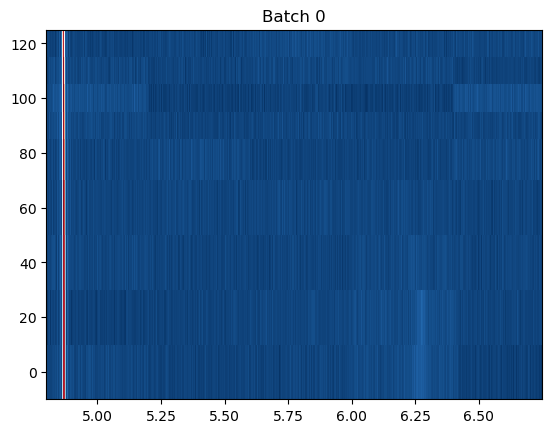

Saved QubitSpec_Batch_1.npz


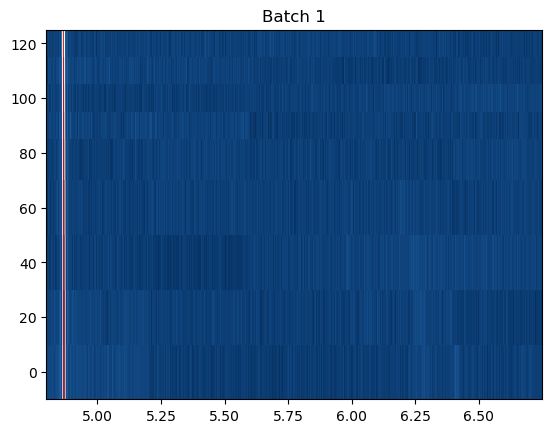

OSError: Can't read data (wrong B-tree signature)

In [4]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

# --- Configuration ---
flux_list = [0e-3, 20e-3, 40e-3, 60e-3, 80e-3, 90e-3, 100e-3, 110e-3, 120e-3]
lo_qubit_values = np.arange(5e9, 6.4e9 + 400e6, 400e6)
CHUNK_SIZE = len(flux_list) * len(lo_qubit_values) # Usually 45

# --- Process in Chunks of 45 ---
for i in range(0, len(grouped_filenames), CHUNK_SIZE):
    batch_files = grouped_filenames[i : i + CHUNK_SIZE]
    batch_index = i // CHUNK_SIZE
    
    final_mag_matrix = []
    stitched_freq_axis = None
    
    # Process the 45 files in this batch
    file_in_batch_idx = 0
    for f_idx in range(len(flux_list)):
        flux_freqs = []
        flux_mags = []
        
        for lo_idx in range(len(lo_qubit_values)):
            if file_in_batch_idx >= len(batch_files): break
            
            filename = batch_files[file_in_batch_idx]
            file_in_batch_idx += 1
            
            with h5py.File(filename, "r") as f:
                lo = f.attrs.get("qubit_lo", lo_qubit_values[lo_idx])
                if_freqs = f["qubit_frequency"][()]
                abs_freqs = (lo + if_freqs) / 1e9
                mag = np.mean(f["Magnitude"][()], axis=0)
                
                flux_freqs.append(abs_freqs)
                flux_mags.append(mag)
        
        # Stitch and subtract mean
        if flux_mags:
            all_f = np.concatenate(flux_freqs)
            all_m = np.concatenate(flux_mags)
            sort_idx = np.argsort(all_f)
            
            # Apply your 5.0 to 6.75 GHz window and mean subtraction
            f_sorted = all_f[sort_idx]
            m_sorted = all_m[sort_idx]
            mask = (f_sorted >= 4.0) & (f_sorted <= 6.75)
            
            if stitched_freq_axis is None:
                stitched_freq_axis = f_sorted[mask]
            
            # Subtract mean to clean up baseline
            processed_trace = m_sorted[mask] - np.mean(m_sorted[mask])
            final_mag_matrix.append(processed_trace)

    # --- Save each batch separately ---
    if final_mag_matrix:
        npz_name = f"QubitSpec_Batch_{batch_index}.npz"
        np.savez_compressed(npz_name, 
                            freq=stitched_freq_axis, 
                            flux=np.array(flux_list)*1e3, 
                            mag=np.array(final_mag_matrix))
        print(f"Saved {npz_name}")

        # Optional: Quick plot for validation
        plt.figure()
        plt.pcolormesh(stitched_freq_axis, np.array(flux_list)*1e3, final_mag_matrix, cmap='RdBu_r')
        plt.title(f"Batch {batch_index}")
        plt.show()


==================== PROCESSING BATCH 0 ====================
Flux (mA)  | LO (GHz)   | Filename
-----------------------------------------------------------------
0.0        | 5.00       | 22-25-56_QubitSpec.hdf5
0.0        | 5.40       | 22-28-12_QubitSpec.hdf5
0.0        | 5.80       | 22-30-29_QubitSpec.hdf5
0.0        | 6.20       | 22-32-45_QubitSpec.hdf5
0.0        | 6.60       | 22-35-01_QubitSpec.hdf5
20.0       | 5.00       | 22-38-02_QubitSpec.hdf5
20.0       | 5.40       | 22-40-19_QubitSpec.hdf5
20.0       | 5.80       | 22-42-34_QubitSpec.hdf5
20.0       | 6.20       | 22-44-51_QubitSpec.hdf5
20.0       | 6.60       | 22-47-07_QubitSpec.hdf5
40.0       | 5.00       | 22-50-08_QubitSpec.hdf5
40.0       | 5.40       | 22-52-25_QubitSpec.hdf5
40.0       | 5.80       | 22-54-41_QubitSpec.hdf5
40.0       | 6.20       | 22-56-57_QubitSpec.hdf5
40.0       | 6.60       | 22-59-14_QubitSpec.hdf5
60.0       | 5.00       | 23-02-14_QubitSpec.hdf5
60.0       | 5.40       | 23-04-31_Qu

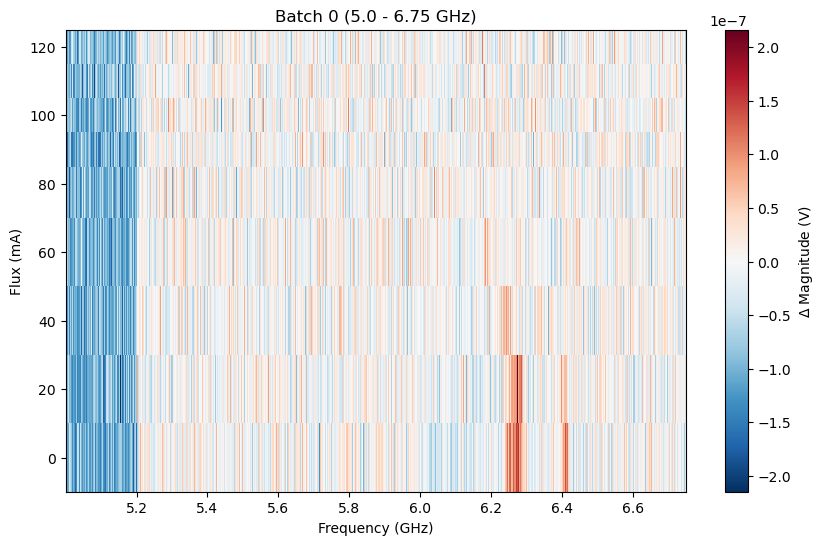


==================== PROCESSING BATCH 1 ====================
Flux (mA)  | LO (GHz)   | Filename
-----------------------------------------------------------------
0.0        | 5.00       | 00-17-04_QubitSpec.hdf5
0.0        | 5.40       | 00-19-20_QubitSpec.hdf5
0.0        | 5.80       | 00-21-37_QubitSpec.hdf5
0.0        | 6.20       | 00-23-54_QubitSpec.hdf5
0.0        | 6.60       | 00-26-10_QubitSpec.hdf5
20.0       | 5.00       | 00-29-09_QubitSpec.hdf5
20.0       | 5.40       | 00-31-25_QubitSpec.hdf5
20.0       | 5.80       | 00-33-41_QubitSpec.hdf5
20.0       | 6.20       | 00-35-56_QubitSpec.hdf5
20.0       | 6.60       | 00-38-13_QubitSpec.hdf5
40.0       | 5.00       | 00-41-14_QubitSpec.hdf5
40.0       | 5.40       | 00-43-30_QubitSpec.hdf5
40.0       | 5.80       | 00-45-46_QubitSpec.hdf5
40.0       | 6.20       | 00-48-02_QubitSpec.hdf5
40.0       | 6.60       | 00-50-18_QubitSpec.hdf5
60.0       | 5.00       | 00-53-17_QubitSpec.hdf5
60.0       | 5.40       | 00-55-33_Qu

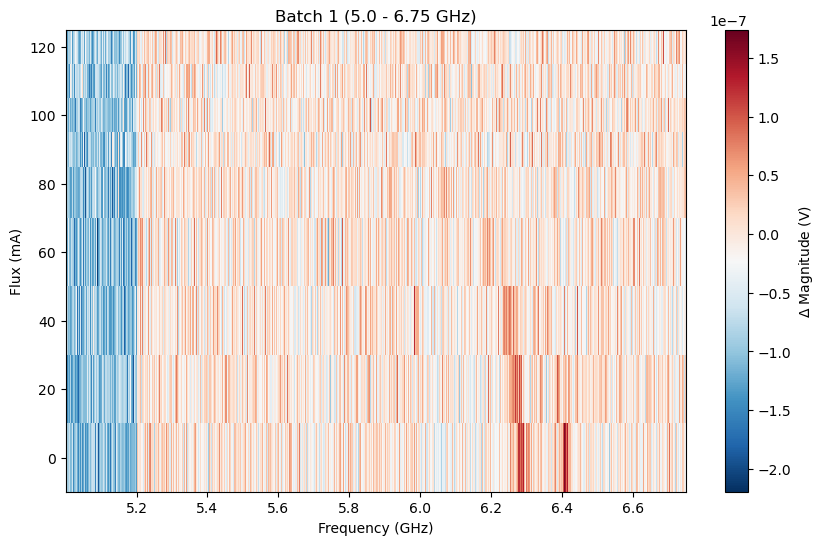


Batch 2 is incomplete (only 17 files). Skipping...


In [5]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os

# --- Configuration ---
flux_list = [0e-3, 20e-3, 40e-3, 60e-3, 80e-3, 90e-3, 100e-3, 110e-3, 120e-3]
lo_qubit_values = np.arange(5e9, 6.4e9 + 400e6, 400e6)
CHUNK_SIZE = 45 # 9 flux * 5 LO

# Iterate through all available data in chunks of 45
for batch_start in range(0, len(grouped_filenames), CHUNK_SIZE):
    batch_idx = batch_start // CHUNK_SIZE
    batch_files = grouped_filenames[batch_start : batch_start + CHUNK_SIZE]
    
    # Check if we have a full batch to process
    if len(batch_files) < CHUNK_SIZE:
        print(f"\nBatch {batch_idx} is incomplete (only {len(batch_files)} files). Skipping...")
        continue

    print(f"\n{'='*20} PROCESSING BATCH {batch_idx} {'='*20}")
    print(f"{'Flux (mA)':<10} | {'LO (GHz)':<10} | {'Filename'}")
    print("-" * 65)

    final_mag_matrix = []
    stitched_freq_axis = None
    file_in_batch_idx = 0

    for f_idx, flux in enumerate(flux_list):
        flux_freqs = []
        flux_mags = []
        
        for lo_idx, lo_val in enumerate(lo_qubit_values):
            filename = batch_files[file_in_batch_idx]
            print(f"{flux*1e3:<10.1f} | {lo_val/1e9:<10.2f} | {os.path.basename(filename)}")
            file_in_batch_idx += 1
            
            try:
                with h5py.File(filename, "r") as f:
                    lo_attr = f.attrs.get("qubit_lo", lo_val)
                    if_freqs = f["qubit_frequency"][()]
                    abs_freqs = (lo_attr + if_freqs) / 1e9
                    
                    mag = np.mean(f["Magnitude"][()], axis=0)
                    # Baseline subtraction: -np.mean
                    flux_mags.append(mag - np.mean(mag))
                    flux_freqs.append(abs_freqs)
            except Exception as e:
                print(f"Error in {filename}: {e}")

        # Stitching logic for the current flux row
        if flux_mags:
            all_f = np.concatenate(flux_freqs)
            all_m = np.concatenate(flux_mags)
            sort_idx = np.argsort(all_f)
            
            f_sorted = all_f[sort_idx]
            m_sorted = all_m[sort_idx]
            mask = (f_sorted >= 5.0) & (f_sorted <= 6.75)
            
            if stitched_freq_axis is None:
                stitched_freq_axis = f_sorted[mask]
            final_mag_matrix.append(m_sorted[mask])

    # --- Save and Plot this specific Batch ---
    if final_mag_matrix:
        save_name = f"QubitSpec_Batch_{batch_idx}.npz"
        np.savez_compressed(save_name, 
                            freq=stitched_freq_axis, 
                            flux=np.array(flux_list)*1e3, 
                            mag=np.array(final_mag_matrix))
        
        plt.figure(figsize=(10, 6))
        plt.pcolormesh(stitched_freq_axis, np.array(flux_list)*1e3, final_mag_matrix, 
                       shading='auto', cmap='RdBu_r')
        plt.colorbar(label='$\Delta$ Magnitude (V)')
        plt.title(f"Batch {batch_idx} (5.0 - 6.75 GHz)")
        plt.xlabel("Frequency (GHz)")
        plt.ylabel("Flux (mA)")
        plt.show()

Processing Incomplete Batch 2 with 17 files...
Error in C:/Users/qcrew/Documents/eunice/data/2026-02-27/02-46-36_QubitSpec.hdf5: Can't read data (wrong B-tree signature)
Flux 60.0mA has only 1 LO windows. Skipping row.
Saved partial data to QubitSpec_Batch2_Incomplete.npz


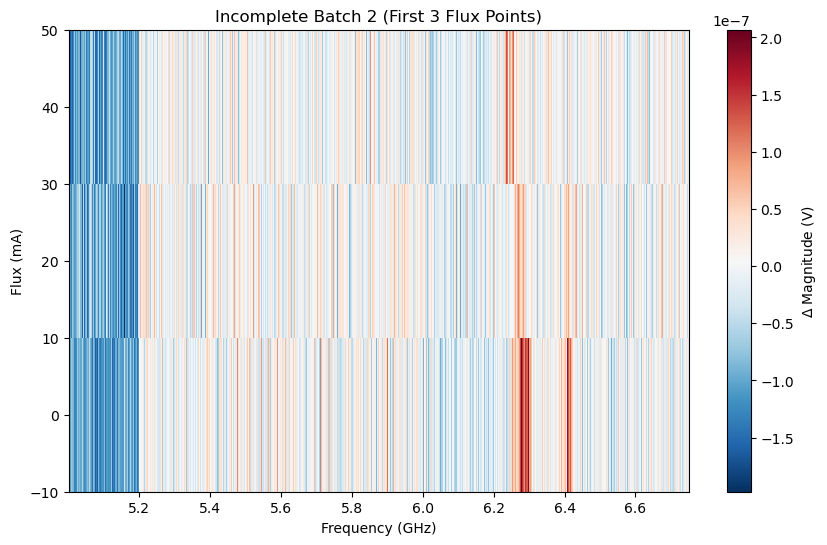

In [6]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os

# --- Parameters ---
flux_list = [0e-3, 20e-3, 40e-3, 60e-3, 80e-3, 90e-3, 100e-3, 110e-3, 120e-3]
lo_qubit_values = np.arange(5e9, 6.4e9 + 400e6, 400e6)
CHUNK_SIZE = 45 

# Target Batch 2 (Starting at index 90)
batch_start = 2 * CHUNK_SIZE
batch_files = grouped_filenames[batch_start:] 

print(f"Processing Incomplete Batch 2 with {len(batch_files)} files...")

final_mag_matrix = []
actual_flux_axis = []
stitched_freq_axis = None
file_idx = 0

for f_idx, flux in enumerate(flux_list):
    if file_idx >= len(batch_files):
        break
        
    flux_freqs = []
    flux_mags = []
    
    for lo_idx, lo_val in enumerate(lo_qubit_values):
        if file_idx >= len(batch_files):
            break
            
        filename = batch_files[file_idx]
        file_idx += 1
        
        try:
            with h5py.File(filename, "r") as f:
                lo_attr = f.attrs.get("qubit_lo", lo_val)
                if_freqs = f["qubit_frequency"][()]
                abs_freqs = (lo_attr + if_freqs) / 1e9
                mag = np.mean(f["Magnitude"][()], axis=0)
                
                flux_freqs.append(abs_freqs)
                flux_mags.append(mag - np.mean(mag))
        except Exception as e:
            print(f"Error in {filename}: {e}")

    # Process if we have the full 5 LO windows
    if len(flux_mags) == len(lo_qubit_values):
        all_f = np.concatenate(flux_freqs)
        all_m = np.concatenate(flux_mags)
        sort_idx = np.argsort(all_f)
        
        f_sorted = all_f[sort_idx]
        m_sorted = all_m[sort_idx]
        mask = (f_sorted >= 5.0) & (f_sorted <= 6.75)
        
        if stitched_freq_axis is None:
            stitched_freq_axis = f_sorted[mask]
        
        final_mag_matrix.append(m_sorted[mask])
        actual_flux_axis.append(flux * 1e3)
    else:
        print(f"Flux {flux*1e3}mA has only {len(flux_mags)} LO windows. Skipping row.")

# --- Save and Plot ---
if final_mag_matrix:
    # Convert list to array for saving
    mag_array = np.array(final_mag_matrix)
    flux_array = np.array(actual_flux_axis)
    
    # Save the partial data
    save_filename = "QubitSpec_Batch2_Incomplete.npz"
    np.savez_compressed(
        save_filename, 
        freq=stitched_freq_axis, 
        flux=flux_array, 
        mag=mag_array
    )
    

    print(f"Saved partial data to {save_filename}")

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(stitched_freq_axis, flux_array, mag_array, 
                   shading='auto', cmap='RdBu_r')
    plt.colorbar(label='$\Delta$ Magnitude (V)')
    plt.title(f"Incomplete Batch 2 (First {len(actual_flux_axis)} Flux Points)")
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Flux (mA)")
    plt.show()
else:
    print("Not enough files to reconstruct even one full flux row.")

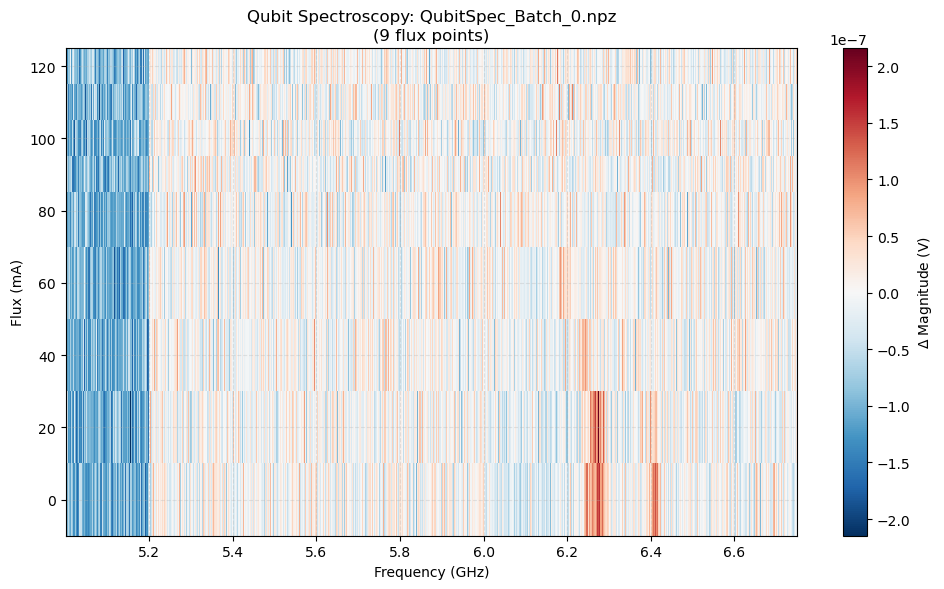

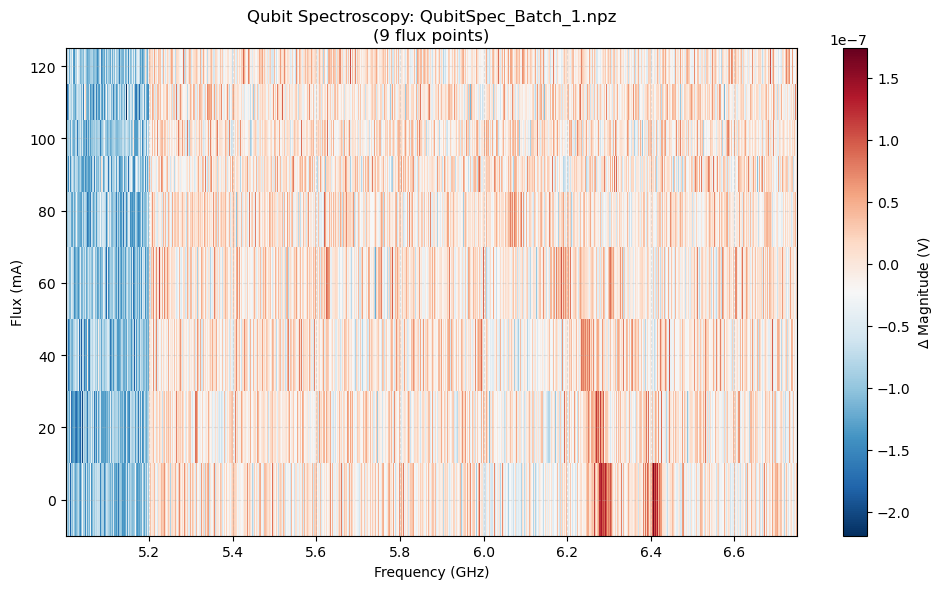

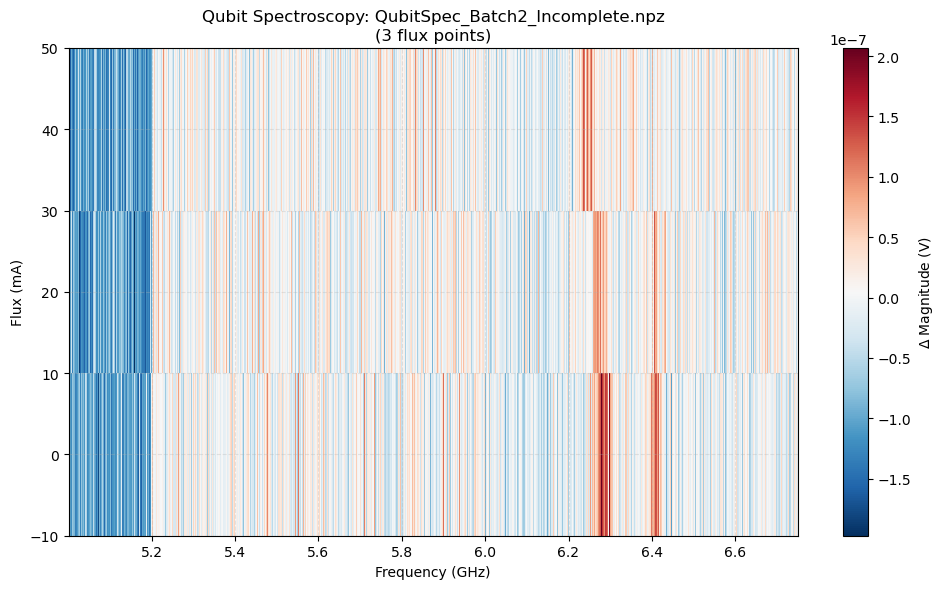

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Define the files ---
files = [
    "QubitSpec_Batch_0.npz", 
    "QubitSpec_Batch_1.npz", 
    "QubitSpec_Batch2_Incomplete.npz"
]

# --- 2. Loop and Plot Individually ---
for f_name in files:
    if not os.path.exists(f_name):
        print(f"Skipping {f_name}: File not found.")
        continue
        
    try:
        data = np.load(f_name)
        
        # Extract data using the keys from your save script
        freq = data['freq']
        flux = data['flux']
        mag = data['mag']
        
        # Create a new figure for each batch
        plt.figure(figsize=(10, 6))
        
        # Plot using pcolormesh
        # cmap='RdBu_r' is great for your mean-subtracted data
        mesh = plt.pcolormesh(freq, flux, mag, shading='auto', cmap='RdBu_r')
        
        plt.colorbar(mesh, label='$\Delta$ Magnitude (V)')
        plt.xlabel('Frequency (GHz)')
        plt.ylabel('Flux (mA)')
        
        # Dynamic title based on filename
        plt.title(f'Qubit Spectroscopy: {f_name}\n({len(flux)} flux points)')
        
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error processing {f_name}: {e}")